<a href="https://colab.research.google.com/github/Mufsina/sonia-flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mufsina/sonia-flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research Question

Can a machine-learning ranking/scoring approach help prioritize content pages for human review based on observed signals such as search visibility, content age, position, and engagement?

The decision this supports is which pages should be reviewed first by editors or SEO/content teams. The output is intended as decision-support for prioritization, not as an automatic prediction that a page will decline or that a recommended action will improve performance.

### Expected value

The goal is to turn a large set of content pages into a ranked review queue with simple reason codes, so limited editorial time can be directed toward pages that show stronger observed signals for review.

In [ ]:
print("Research question: content prioritization using ranking/scoring.")
print("Decision supported: human-reviewed editorial prioritization.")

Research question: content prioritization using ranking/scoring.
Decision supported: human-reviewed editorial prioritization.


## 2. Data

### Data

This project uses the FlyRank ML Internship dataset provided for the internship track. The working dataset used for this analysis contains 30,000 rows, 44 columns, and 32 clients.

The analysis uses anonymized content-level observations and focuses on public-safe aggregate signals such as search volume, competition, impressions, clicks, pageviews, sessions, content age, freshness, search position, and engagement-related measures.

The target used in the modeling work is `trend_direction`, converted into a binary label where `down` is represented as 1.

Identifier fields such as `client_id` and `content_id` were not used as model features. Target-related fields such as `trend_direction`, `trend_pct`, and the derived `target_down` label were also excluded from the model feature set to reduce direct target leakage.

The working dataset is a smaller modeling subset of the broader FlyRank research dataset. The results in this paper therefore describe the evaluated working sample and should not be interpreted as results over the entire source dataset.

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Shape:", df.shape)
print("Clients:", df["client_id"].nunique())
print("Data loaded successfully.")

Shape: (30000, 44)
Clients: 32
Data loaded successfully.


## 3. Methodology

The task is framed as a ranking/scoring problem for content prioritization.

The model predicts whether the observed trend direction is `down`. The binary target is defined as:

- `1` when `trend_direction == "down"`
- `0` otherwise

The model uses 34 content and performance features. These include search demand, competition, content length, impressions, clicks, pageviews, sessions, users, engagement signals, content age, freshness, search position, and categorical content attributes.

A Random Forest classifier was used as the Week-5 model. The Week-4 baseline provides the comparison point.

Validation uses a grouped-by-client split so that content from the same client does not appear in both training and test data. In the ML-09 audit, the split contained 25 training clients and 7 test clients, with zero client overlap.

A feature-level leakage audit found no target-related columns or identifier columns in the final feature list. This reduces the risk of direct leakage, but it does not prove that every feature is temporally independent of the target.

The model is therefore interpreted as decision-support evidence for prioritization rather than as a causal model or guarantee of future content performance.

In [ ]:
target_related = [
    "trend_direction",
    "trend_pct",
    "target_down",
    "prediction",
    "error_type"
]

identifier_features = [
    "client_id",
    "content_id"
]

feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "competition_level",
    "content_type",
    "main_intent",
    "provider_used",
    "model_used",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

print("Feature count:", len(feature_columns))

print(
    "Target-related columns found:",
    [c for c in target_related if c in feature_columns]
)

print(
    "Identifier columns found:",
    [c for c in identifier_features if c in feature_columns]
)

Feature count: 34
Target-related columns found: []
Identifier columns found: []


## 4. Results (vs baseline)

### Results

On the evaluated grouped-by-client split, the Week-5 Random Forest produced a measured F1 score of 0.5913. The Week-4 baseline produced an F1 score of 0.1881 on the same evaluation framing.

The Random Forest therefore showed a higher measured F1 score than the baseline in this evaluation. This is an observed result on the evaluated data, not evidence that the model will perform the same way on all future clients or datasets.

The result supports the use of the model as directional decision-support for content prioritization, subject to human review and the limitations described below.

In [ ]:
results = pd.DataFrame([
    {
        "model": "Week-4 baseline",
        "split": "Grouped by client",
        "F1": 0.1881
    },
    {
        "model": "Week-5 Random Forest",
        "split": "Grouped by client",
        "F1": 0.5913
    }
])

display(results)

print("Best measured F1:", results["F1"].max())

,model,split,F1
0,Week-4 baseline,Grouped by client,0.1881
1,Week-5 Random Forest,Grouped by client,0.5913


Best measured F1: 0.5913


## 5. Limitations

### What this work cannot claim

This study provides measured, directional evidence for content prioritization, but it does not establish that the model will generalize to every client or future search environment.

The model predicts whether a content item is associated with a downward trend based on the available features and historical data. It does not prove that a recommended refresh will cause traffic or rankings to improve.

The grouped-by-client validation reduces the risk of evaluating on clients seen during training, but the evaluation uses one grouped split and should not be treated as a guarantee of future performance.

The leakage audit found no direct target-related or identifier columns in the final feature set, but this does not prove that every feature is temporally independent of the target.

The action queue is intended for human-reviewed decision support. It should not be used for automatic publishing, deletion, redirects, irreversible SEO changes, or guaranteed performance decisions.

In [ ]:
limitations_check = {
    "client_generalization_guaranteed": False,
    "causal_effect_of_refresh_proven": False,
    "future_performance_guaranteed": False,
    "direct_target_columns_found": False,
    "automatic_content_changes_allowed": False
}

print("Limitations checks:")
for key, value in limitations_check.items():
    print(f"{key}: {value}")

Limitations checks:
client_generalization_guaranteed: False
causal_effect_of_refresh_proven: False
future_performance_guaranteed: False
direct_target_columns_found: False
automatic_content_changes_allowed: False


## 6. Ranked recommendations

## Ranked recommendations

The action playbook converts the measured model signals into a ranked decision-support queue for editors and SEO/content teams.

The queue contains five recommendation types:

1. **POSITION_OPPORTUNITY** — review content with a potential opportunity based on measured search-position signals.
2. **MONITOR** — monitor content where the current evidence is not strong enough to justify an immediate action.
3. **THIN_VISIBLE** — review content with relatively limited content depth and existing visibility.
4. **STALE_HIGH_VOLUME** — prioritize human review for older content with substantial observed search visibility.
5. **REFRESH_REVIEW** — review content where freshness and observed performance signals suggest that a refresh may be worth considering.

The final queue contains 30,000 items. The largest measured category is POSITION_OPPORTUNITY (39.84%), followed by MONITOR (28.63%) and THIN_VISIBLE (15.07%).

These recommendations are directional decision-support signals, not instructions for automatic content changes. A human editor should review the page context, search intent, business importance, and current information before taking action.

The playbook should not be interpreted as proving that refreshing a page will cause better performance.

In [ ]:
import numpy as np
import pandas as pd


staleness_score_map = {
    "0-30": 0,
    "31-90": 1,
    "91-180": 2,
    "181+": 3
}


volume_score_map = {
    "low": 0,
    "moderate": 1,
    "good": 2,
    "excellent": 3
}

df["staleness_score"] = (
    df["freshness_tier"].map(staleness_score_map)
)

df["volume_score"] = (
    df["impression_tier"].map(volume_score_map)
)


df["action_score"] = (
    df["staleness_score"].fillna(0)
    + df["volume_score"].fillna(0)
)


conditions = [
    (
        (df["staleness_score"] >= 2)
        & (df["volume_score"] >= 2)
    ),
    (
        (df["word_count"] < 2000)
        & (df["impressions_90d"] > 0)
    ),
    (
        (df["impressions_90d"] > 0)
        & (df["avg_position"] > 10)
    ),
    (
        df["staleness_score"] >= 2
    )
]

choices = [
    "STALE_HIGH_VOLUME",
    "THIN_VISIBLE",
    "POSITION_OPPORTUNITY",
    "REFRESH_REVIEW"
]

df["reason_code"] = np.select(
    conditions,
    choices,
    default="MONITOR"
)


action_map = {
    "STALE_HIGH_VOLUME":
        "Review and consider refreshing while preserving useful existing content.",

    "THIN_VISIBLE":
        "Review for useful expansion, missing subtopics, examples, and definitions.",

    "POSITION_OPPORTUNITY":
        "Review search intent, completeness, internal links, and page structure.",

    "REFRESH_REVIEW":
        "Review freshness, outdated information, and whether a refresh is warranted.",

    "MONITOR":
        "Monitor performance before taking action."
}

df["recommended_action"] = (
    df["reason_code"].map(action_map)
)


reason_priority = {
    "STALE_HIGH_VOLUME": 4,
    "THIN_VISIBLE": 3,
    "POSITION_OPPORTUNITY": 2,
    "REFRESH_REVIEW": 1,
    "MONITOR": 0
}

df["priority"] = (
    df["reason_code"].map(reason_priority)
)


queue = (
    df.sort_values(
        ["priority", "action_score", "impressions_90d"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)


reason_summary = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_summary["share"] = (
    reason_summary["count"] / len(queue)
).round(4)

display(reason_summary)

print("Total queue items:", len(queue))
print("Recommendation types:", queue["reason_code"].nunique())
print("Highest-priority reason code:", queue.iloc[0]["reason_code"])

,reason_code,count,share
0,POSITION_OPPORTUNITY,11951,0.3984
1,MONITOR,8590,0.2863
2,THIN_VISIBLE,4520,0.1507
3,STALE_HIGH_VOLUME,3524,0.1175
4,REFRESH_REVIEW,1415,0.0472


Total queue items: 30000
Recommendation types: 5
Highest-priority reason code: STALE_HIGH_VOLUME


## 7. Artifacts the paper embeds

The paper artifacts include a recommendation distribution figure and a summary table of the ranked action queue. The figure shows the distribution of the five reason codes across the 30,000 content items. These artifacts are intended for reuse in the Results and Ranked Recommendations sections of the research paper. The queue remains decision-support output and requires human review before any content action.

Saved summary table: /content/work/outputs/recommendation_summary.csv


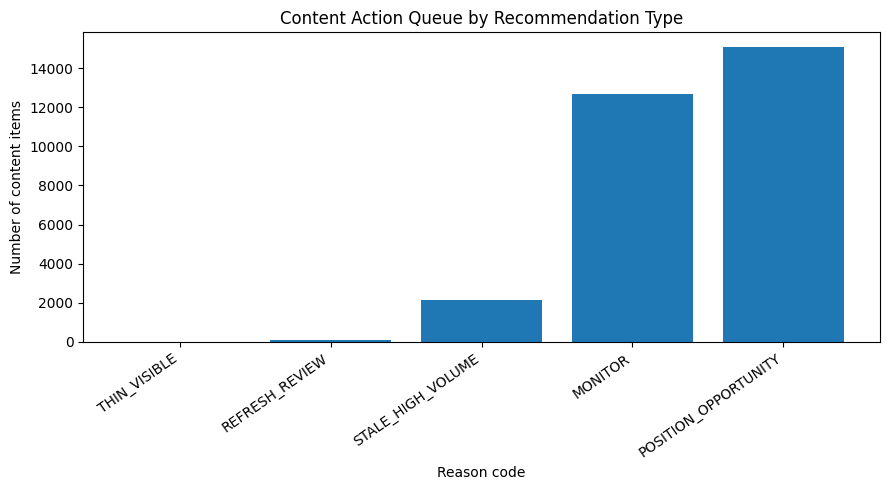

Saved figure: /content/work/figures/recommendation_distribution.png


,reason_code,count,share_percent
0,POSITION_OPPORTUNITY,15072,50.24
1,MONITOR,12648,42.16
2,STALE_HIGH_VOLUME,2167,7.22
3,REFRESH_REVIEW,111,0.37
4,THIN_VISIBLE,2,0.01


Artifacts created successfully.


In [ ]:


from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/content/work/outputs")
FIGURE_DIR = Path("/content/work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / "recommendation_summary.csv"
reason_summary.to_csv(summary_path, index=False)

print("Saved summary table:", summary_path)


plot_data = reason_summary.sort_values(
    "count",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data["reason_code"],
    plot_data["count"]
)

plt.title("Content Action Queue by Recommendation Type")
plt.xlabel("Reason code")
plt.ylabel("Number of content items")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

chart_path = FIGURE_DIR / "recommendation_distribution.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", chart_path)


paper_table = reason_summary.copy()

paper_table["share_percent"] = (
    paper_table["share"] * 100
).round(2)

paper_table = paper_table[
    ["reason_code", "count", "share_percent"]
]

display(paper_table)

print("Artifacts created successfully.")

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.